In [1]:
from selenium import webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
import pandas as pd
from kiwipiepy import Kiwi
from wordcloud import WordCloud as wc
from collections import Counter
from tqdm import tqdm
import re
import matplotlib.pyplot as plt

In [2]:
# 문자열 전처리 함수 -> 숫자, 문자, (?,!,) 제외하고 공백으로 대체
def preprocess_sentence_kr(w):
    w = w.strip()
    w = re.sub(r"[^0-9가-힣A-Za-z?.!,]+"," ", w)
    w = w.strip()
    return w

In [3]:
from urllib.parse import quote

In [4]:
keyword = quote("LG ThinQ앱")

In [5]:
keyword

'LG%20ThinQ%EC%95%B1'

In [6]:
date_option = "1y"

In [7]:
url = f"https://search.naver.com/search.naver?ssc=tab.blog.all&query={keyword}&sm=tab_opt&nso=so%3Ar%2Cp%3A{date_option}"

In [8]:
url

'https://search.naver.com/search.naver?ssc=tab.blog.all&query=LG%20ThinQ%EC%95%B1&sm=tab_opt&nso=so%3Ar%2Cp%3A1y'

In [9]:
driver = wb.Chrome()
driver.get(url)

In [10]:
scroll = driver.find_element(By.TAG_NAME,'body')


In [11]:
try:
    for i in range(100):
        scroll.send_keys(Keys.END)
        time.sleep(1)
except:
    pass

In [12]:
driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.jc59IQoHJVaiFTctwPf1')[0]

<selenium.webdriver.remote.webelement.WebElement (session="b3d0e6e4fd667697003100f285b58f72", element="f.51B750823DCD8721AA51129474884D07.d.74311A70184004A9727CB9876E3D1392.e.456")>

In [12]:
link = driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.jc59IQoHJVaiFTctwPf1')

In [13]:
href_list = [l.get_attribute('href') for l in link]

In [14]:
len(href_list)

1020

In [ ]:
href_list[0]

In [19]:
driver.get(href_list[0])

In [20]:
driver.switch_to.frame('mainFrame')
text = driver.find_element(By.CSS_SELECTOR,'div.se-main-container').text
content = preprocess_sentence_kr(text)

In [21]:
content

'TV 대신 미니빔 ? 엘지 시네빔 쇼츠 구매 후기 휴대용 LG 빔프로젝터 추천 TV 대신 미니빔 ? 엘지 시네빔 쇼츠 구매 후기 휴대용 LG 빔프로젝터 추천 최근에 아이들의 미디어... blog.naver.com lg 시네빔 매직 리모컨 대체 LG ThinQ 앱 연결하기 지난 리뷰를 통해 LG시네빔을 TV 대신 설치하여 사용한 후기를 공유했었습니다. 작은 크기에 단초점이라 공간을 옮겨 다니며, 구매 이후 매일매일 잘 사용하고 있는데요. 하지만 리뷰에서도 언급했듯 LG 시네빔을 사용하면서 가장 답답했던 부분은 매직 리모컨이 제대로 작동하지 않는다는 점이었습니다. 특히 포인터 기능이 끊기거나, 버튼 입력이 딜레이 되는 경우가 자주 발생했습니다. 쓰다 보면 소프트웨어 업데이트 통해 해결되겠지 싶었지만, 8282의 민족답게 기다릴 수가 없겠더군요. 제가 구매한 제품 외에도 휴대용 시네빔 모델은 리모컨 수신 감도가 약해 포인터가 튀거나 커서가 엉뚱한 곳으로 이동하는 경우도 흔합니다. 이런 문제를 해결할 수 있는 현실적인 대안이 바로 LG ThinQ 앱입니다. 목차 LG ThinQ란 무엇인가. 시네빔을 LG ThinQ 앱으로 연결하는 방법. 매직 리모컨 대신 LG ThinQ 앱 추천! 1. LG ThinQ란 무엇인가. LG ThinQ는 LG전자가 개발한 통합 스마트홈 플랫폼입니다. 이 앱은 LG 가전제품 전반을 스마트폰 하나로 제어할 수 있는 시스템입니다. TV, 냉장고, 세탁기, 공기청정기 등 다양한 제품을 한곳에서 관리할 수 있습니다. 연동해둔 스마트폰으로 LG 기기 상태를 확인하거나, 전원 제어, 소모품 교체 알림, 자동화 설정 등도 가능합니다. LG ThinQ 앱에 LG TV 연결하기 재생 41 좋아요 0 02 27 접기 펴기 LG ThinQ 앱에 LG TV 연결하기 LG ThinQ App FAQ 한국 사용자는 집 안의 모든 LG 가전을 하나의 앱으로 관리할 수 있으며, 외부에서도 원격으로 제어할 수 있습니다. 가전 이름에 씽큐가 붙어있어서 앱이나 플랫폼이 아닌

In [22]:
f = open("./LG ThinQ앱 블로그데이터.txt","w")

for l in tqdm(href_list):
    try:
        driver.get(l)
        driver.switch_to.frame('mainFrame')
        text = driver.find_element(By.CSS_SELECTOR,'div.se-main-container').text
        content = preprocess_sentence_kr(text)
        f.write(content)
    except:
        pass
f.close()

100%|████████████████████████████████████████████████████████████████████████████| 1020/1020 [1:33:32<00:00,  5.50s/it]


In [23]:
keyword = quote("LG ThinQ어플")

In [24]:
def thinq_app(kwd):
    date_option = "1y"
    url = f"https://search.naver.com/search.naver?ssc=tab.blog.all&query={kwd}&sm=tab_opt&nso=so%3Ar%2Cp%3A{date_option}"
    driver = wb.Chrome()
    driver.get(url)
    scroll = driver.find_element(By.TAG_NAME,'body')
    try:
        for i in range(100):
            scroll.send_keys(Keys.END)
            time.sleep(1)
    except:
        pass
    link = driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.jc59IQoHJVaiFTctwPf1')
    href_list = [l.get_attribute('href') for l in link]
    f = open("./LG ThinQ어플 블로그데이터.txt","w")
    for l in tqdm(href_list):
        try:
            driver.get(l)
            driver.switch_to.frame('mainFrame')
            text = driver.find_element(By.CSS_SELECTOR,'div.se-main-container').text
            content = preprocess_sentence_kr(text)
            f.write(content)
        except:
            pass
    f.close()

In [25]:
thinq_app(keyword)

100%|██████████████████████████████████████████████████████████████████████████████| 920/920 [1:38:29<00:00,  6.42s/it]


In [3]:
f = open("./LG ThinQ앱 블로그데이터.txt","r")
words = f.readline()
f.close()

In [4]:
kiwi = Kiwi()

In [6]:
token = kiwi.tokenize(words)

In [16]:
nn_list = [t.form for t in token if t.tag in ['NNG','NNP','VV']]

In [17]:
counter = Counter(nn_list)

In [18]:
top_100 = counter.most_common(100)

In [19]:
from wordcloud import WordCloud as wc

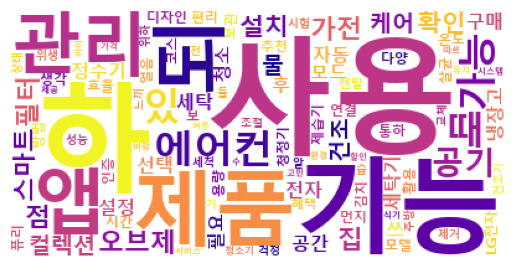

In [20]:
wc = wc(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white' ,
    # mask = mask,
    colormap = "plasma"
).generate_from_frequencies(dict(top_100))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [5]:
keyword

'LG%20ThinQ%EC%95%B1'

In [6]:
date_option = "1y"

In [7]:
url = f"https://search.naver.com/search.naver?ssc=tab.blog.all&query={keyword}&sm=tab_opt&nso=so%3Ar%2Cp%3A{date_option}"

In [8]:
url

'https://search.naver.com/search.naver?ssc=tab.blog.all&query=LG%20ThinQ%EC%95%B1&sm=tab_opt&nso=so%3Ar%2Cp%3A1y'

In [9]:
driver = wb.Chrome()
driver.get(url)

In [10]:
scroll = driver.find_element(By.TAG_NAME,'body')


In [11]:
try:
    for i in range(100):
        scroll.send_keys(Keys.END)
        time.sleep(1)
except:
    pass

In [12]:
driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.jc59IQoHJVaiFTctwPf1')[0]

<selenium.webdriver.remote.webelement.WebElement (session="b3d0e6e4fd667697003100f285b58f72", element="f.51B750823DCD8721AA51129474884D07.d.74311A70184004A9727CB9876E3D1392.e.456")>

In [12]:
link = driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.jc59IQoHJVaiFTctwPf1')

In [13]:
href_list = [l.get_attribute('href') for l in link]

In [14]:
len(href_list)

1020

In [ ]:
href_list[0]

In [19]:
driver.get(href_list[0])

In [20]:
driver.switch_to.frame('mainFrame')
text = driver.find_element(By.CSS_SELECTOR,'div.se-main-container').text
content = preprocess_sentence_kr(text)

In [21]:
content

'TV 대신 미니빔 ? 엘지 시네빔 쇼츠 구매 후기 휴대용 LG 빔프로젝터 추천 TV 대신 미니빔 ? 엘지 시네빔 쇼츠 구매 후기 휴대용 LG 빔프로젝터 추천 최근에 아이들의 미디어... blog.naver.com lg 시네빔 매직 리모컨 대체 LG ThinQ 앱 연결하기 지난 리뷰를 통해 LG시네빔을 TV 대신 설치하여 사용한 후기를 공유했었습니다. 작은 크기에 단초점이라 공간을 옮겨 다니며, 구매 이후 매일매일 잘 사용하고 있는데요. 하지만 리뷰에서도 언급했듯 LG 시네빔을 사용하면서 가장 답답했던 부분은 매직 리모컨이 제대로 작동하지 않는다는 점이었습니다. 특히 포인터 기능이 끊기거나, 버튼 입력이 딜레이 되는 경우가 자주 발생했습니다. 쓰다 보면 소프트웨어 업데이트 통해 해결되겠지 싶었지만, 8282의 민족답게 기다릴 수가 없겠더군요. 제가 구매한 제품 외에도 휴대용 시네빔 모델은 리모컨 수신 감도가 약해 포인터가 튀거나 커서가 엉뚱한 곳으로 이동하는 경우도 흔합니다. 이런 문제를 해결할 수 있는 현실적인 대안이 바로 LG ThinQ 앱입니다. 목차 LG ThinQ란 무엇인가. 시네빔을 LG ThinQ 앱으로 연결하는 방법. 매직 리모컨 대신 LG ThinQ 앱 추천! 1. LG ThinQ란 무엇인가. LG ThinQ는 LG전자가 개발한 통합 스마트홈 플랫폼입니다. 이 앱은 LG 가전제품 전반을 스마트폰 하나로 제어할 수 있는 시스템입니다. TV, 냉장고, 세탁기, 공기청정기 등 다양한 제품을 한곳에서 관리할 수 있습니다. 연동해둔 스마트폰으로 LG 기기 상태를 확인하거나, 전원 제어, 소모품 교체 알림, 자동화 설정 등도 가능합니다. LG ThinQ 앱에 LG TV 연결하기 재생 41 좋아요 0 02 27 접기 펴기 LG ThinQ 앱에 LG TV 연결하기 LG ThinQ App FAQ 한국 사용자는 집 안의 모든 LG 가전을 하나의 앱으로 관리할 수 있으며, 외부에서도 원격으로 제어할 수 있습니다. 가전 이름에 씽큐가 붙어있어서 앱이나 플랫폼이 아닌

In [21]:
f = open("./LG ThinQ어플 블로그데이터.txt","r")
word = f.readline()
f.close()

In [22]:
kiwi = Kiwi()

In [23]:
token = kiwi.tokenize(word)

In [24]:
nn_list = [t.form for t in token if t.tag in ['NNG','NNP','VV']]

In [25]:
counter = Counter(nn_list)

In [26]:
top_100 = counter.most_common(100)

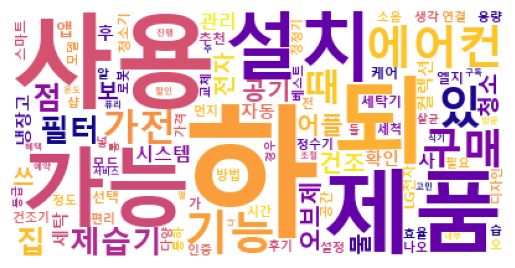

In [28]:
wc = wc(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white' ,
    # mask = mask,
    colormap = "plasma"
).generate_from_frequencies(dict(top_100))
plt.imshow(wc)
plt.axis('off')
plt.show()